# Gradient Boosting — Health Insurance Cross-Sell

**Goal:** Predict which existing health-insurance customers will be interested in vehicle
insurance (`Response` = 1), so the company can focus its cross-sell outreach.

This notebook covers the Gradient Boosting model end to end: data preparation on the
agreed feature set, training with class-imbalance handling, evaluation, and a
business-oriented threshold analysis.

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, precision_score, recall_score, f1_score)

## Load Data

`Annual_Premium` is converted from Indian Rupees to US Dollars (approx. 83:1) for
readability. This rescaling does not affect model performance.

In [3]:
df = pd.read_csv("/Users/gavalencia/Desktop/insurance_data/train.csv")
df["Annual_Premium"] = (df["Annual_Premium"] / 83).round(2)   # rupees -> dollars
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,487.40,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,404.05,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,461.37,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,344.81,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,331.28,152.0,39,0


## Data Preparation (Agreed Feature Set)

Drop `id` and `Driving_License` (nearly constant — 99.8% of customers hold a license).
Encode binary and ordinal features, and one-hot encode the categorical `Region_Code` and
`Policy_Sales_Channel` (they are labels, not quantities). `Vintage` is retained: despite
near-zero linear correlation, it carries non-linear predictive value for tree models.

In [4]:
df_model = df.drop(columns=["id", "Driving_License"])
df_model["Gender"] = df_model["Gender"].map({"Male": 1, "Female": 0})
df_model["Vehicle_Damage"] = df_model["Vehicle_Damage"].map({"Yes": 1, "No": 0})
df_model["Vehicle_Age"] = df_model["Vehicle_Age"].map({"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})
df_model = pd.get_dummies(df_model, columns=["Region_Code", "Policy_Sales_Channel"])
print("Shape:", df_model.shape)

Shape: (381109, 216)


In [5]:
x = df_model.drop(columns=["Response"])
y = df_model["Response"]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42)
print(x_train.shape, x_test.shape)

(304887, 215) (76222, 215)


## Gradient Boosting Model

### Class Imbalance

The target is imbalanced (~88% not interested, ~12% interested). Unlike Logistic
Regression and Random Forest, `GradientBoostingClassifier` has no `class_weight`
parameter, so we apply **balanced sample weights** during training via
`compute_sample_weight`. This up-weights the minority (interested) class without resampling
the data, keeping the comparison with the other models fair.

In [6]:
w = compute_sample_weight(class_weight="balanced", y=y_train)

gb = GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                learning_rate=0.1, random_state=42)
gb.fit(x_train, y_train, sample_weight=w)

gb_prob = gb.predict_proba(x_test)[:, 1]
print("GB ROC-AUC:", round(roc_auc_score(y_test, gb_prob), 4))
print("GB Average Precision:", round(average_precision_score(y_test, gb_prob), 4))

GB ROC-AUC: 0.8573
GB Average Precision: 0.3687


### Evaluation at Default Threshold (0.50)

The default 0.50 cutoff provides a consistent basis for comparing models.

In [7]:
gb_pred = (gb_prob >= 0.50).astype(int)
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

[[45652 21228]
 [  775  8567]]
              precision    recall  f1-score   support

           0       0.98      0.68      0.81     66880
           1       0.29      0.92      0.44      9342

    accuracy                           0.71     76222
   macro avg       0.64      0.80      0.62     76222
weighted avg       0.90      0.71      0.76     76222



### Feature Importances

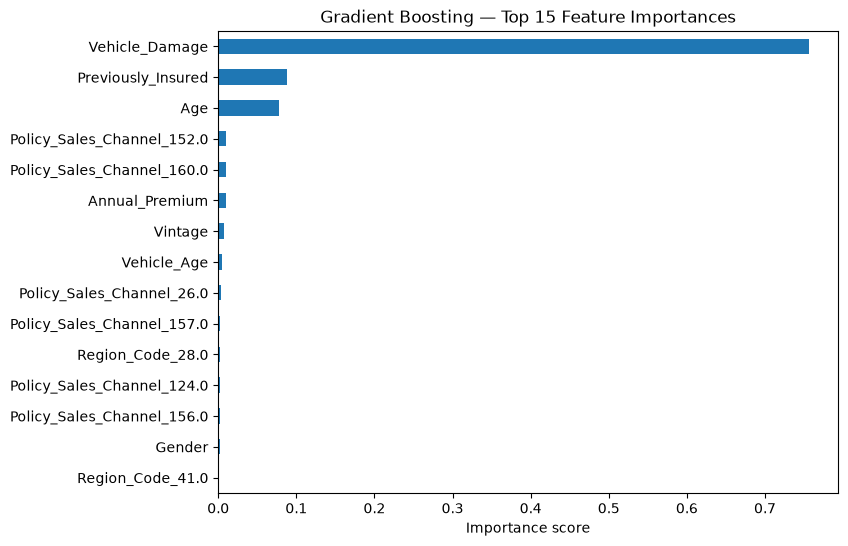

In [8]:
gb_importances = pd.Series(gb.feature_importances_, index=x.columns).sort_values(ascending=False)
gb_importances.head(15).plot(kind="barh", figsize=(8, 6),
                             title="Gradient Boosting — Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.xlabel("Importance score")
plt.show()

## Classification Threshold Analysis

ROC-AUC is threshold-independent and stays constant; precision, recall, and F1 shift with
the cutoff. In this cross-sell context, missing an interested customer (lost revenue)
costs more than a wasted contact (a cheap email), so lower thresholds that favor recall
are generally preferred.

In [9]:
gb_auc = roc_auc_score(y_test, gb_prob)

def evaluate_threshold(t):
    pred = (gb_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"Threshold = {t}")
    print(f"  ROC-AUC:   {gb_auc:.3f}  (constant)")
    print(f"  Precision: {precision_score(y_test, pred):.3f}")
    print(f"  Recall:    {recall_score(y_test, pred):.3f}")
    print(f"  F1:        {f1_score(y_test, pred):.3f}")
    print(f"  Contacted: {tp+fp:,}  |  Buyers reached: {tp:,} of {tp+fn:,}")
    print()

for t in [0.50, 0.15]:
    evaluate_threshold(t)

Threshold = 0.5
  ROC-AUC:   0.857  (constant)
  Precision: 0.288
  Recall:    0.917
  F1:        0.438
  Contacted: 29,795  |  Buyers reached: 8,567 of 9,342

Threshold = 0.15
  ROC-AUC:   0.857  (constant)
  Precision: 0.237
  Recall:    0.993
  F1:        0.382
  Contacted: 39,190  |  Buyers reached: 9,278 of 9,342



**Threshold conclusion:** At the default **0.50** cutoff the model is conservative (higher
precision, lower recall). Lowering the threshold to **0.15** near the ~12% base rate of
interested customers captures the large majority of buyers at the cost of more false
alarms. Because a wasted email costs far less than a missed sale, the lower threshold
aligns best with the cross-sell objective. We report the model at 0.50 for a fair
comparison.

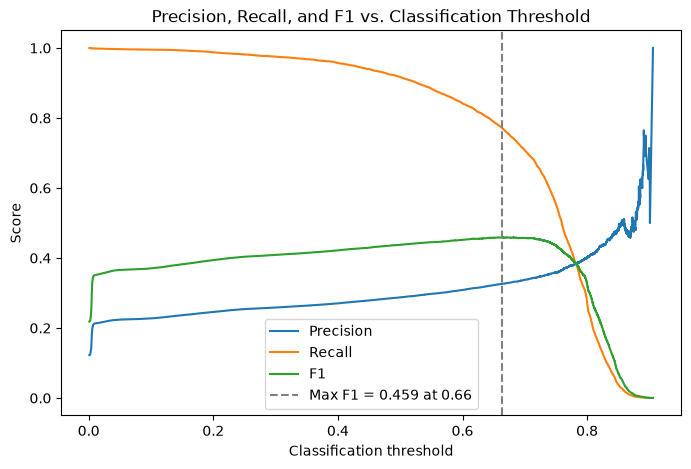

In [10]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, gb_prob)
prec, rec = prec[:-1], rec[:-1]
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best = f1.argmax()

plt.figure(figsize=(8, 5))
plt.plot(thr, prec, label="Precision")
plt.plot(thr, rec, label="Recall")
plt.plot(thr, f1, label="F1")
plt.axvline(thr[best], color="gray", ls="--",
            label=f"Max F1 = {f1[best]:.3f} at {thr[best]:.2f}")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs. Classification Threshold")
plt.legend()
plt.show()


### Precision–Recall Trade-off Across Thresholds

Checking two cutoffs only gives us two points. Sweeping the full range shows the whole
trade-off: as the threshold rises, recall drops and precision climbs. F1 peaks where
they balance, marked by the dashed line. That peak is well above 0.50, but it treats a
missed buyer and a wasted email as equally costly, which is not our situation.
